In [1]:
#This example will highlight the find cluster tool by inputting right ascension and declination coordinates of the cluster as well as plot the cluster


In [2]:
#We will start by importing the gaia input module and the mean photometry module. We will query the data and then plot the cluster
import sys, os
sys.path.append(os.path.abspath(".."))
from gaia_analysis_tools import gaia_input as gi
from gaia_analysis_tools import mean_photometry as mphot

In [3]:
#This is optional but logging into Gaia Archive using credentials may resolve any access issues when querying
#gi.gaia_login_prompt()

Cluster search near (ra=160.8, dec=-64.4), radius 2.0 deg:
  -> 13786 star(s) found.
  -> skipped 3196 member link(s) below membership_certainty 80.
  -> grouped into 45 candidate cluster(s).
  -> returning top 6 by member count.


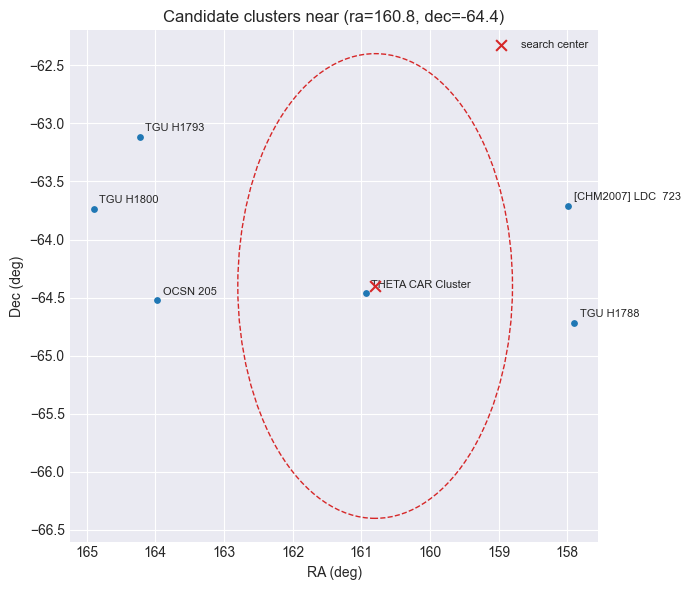

,name,common_name,member_count,ra,dec,otype,separation_deg,implied_distance_pc
0,IC 2602,THETA CAR Cluster,368,160.936331,-64.462423,OpC,0.085783,151.678321
1,OCSN 205,None,3,163.975851,-64.523147,OpC,1.374542,151.689825
2,TGU H1788,None,2,157.897917,-64.718333,DNe,1.286547,NaN
3,[CHM2007] LDC 723,None,1,157.988580,-63.708500,GrG,1.410923,NaN
4,TGU H1800,None,1,164.900000,-63.733333,DNe,1.912539,NaN
5,TGU H1793,None,1,164.225000,-63.116667,DNe,1.984565,NaN


In [5]:
#now calling the function and putting the coordinates for the IC 2602 cluster for reference. The function should find the closest cluster which in this case should show IC 2602
gi.find_cluster(ra = 160.8, dec = -64.4, dist_min= 151.5, dist_max = 152.5)

#Below should be printed the name of the closest cluster found nearby these coordinates

Resolving 'IC 2602', membership_certainty >= 80:
  -> 6229 raw membership link(s) from SIMBAD.
  -> 1673 unique star name(s) after removing duplicates.
  -> 1665 resolved to a Gaia DR3 ID (8 could not be resolved).
                              name common_name              gaia_id  \
0            1RXS J095649.1-635934        None  5249652940088576896   
1          2MASS J08092141-4708065        None  5519272982440000768   
2          2MASS J08104428-4727558        None  5519204331680657536   
3          2MASS J08104880-4727223        None  5519204434762489088   
4          2MASS J08111195-6656400        None  5271426397057175936   
...                            ...         ...                  ...   
1668  Gaia DR2 5302242954911820928        None                 <NA>   
1669                     HD  91895        None                 <NA>   
1670                     HD  92467        None                 <NA>   
1671                     HD  92570        None                 <NA>   
1672

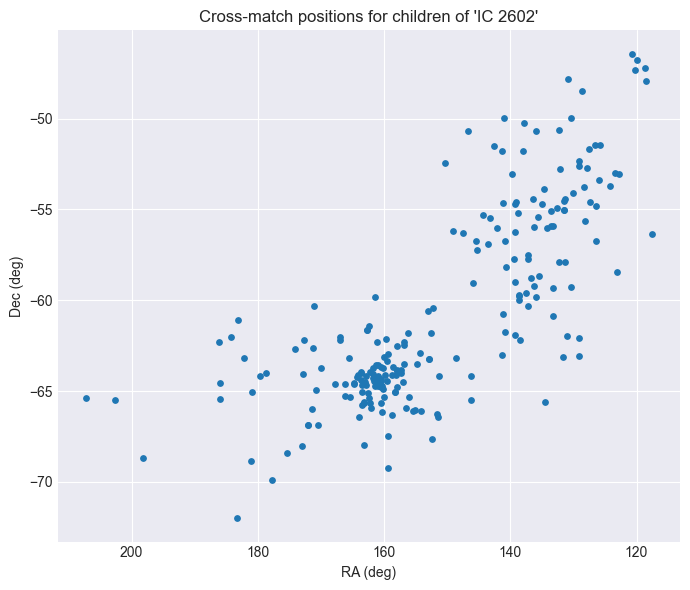

Retrieved 1665 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,5226406515506594560,Gaia DR3 5226406515506594560,165.839437,-72.787399,5.913695,-17.615244,11.082608,11.689121,12.131037,11.060328
1,5234867944690161024,Gaia DR3 5234867944690161024,168.259779,-68.123589,7.924953,-24.372118,12.462855,16.990017,19.111473,15.649081
2,5238048969264890880,Gaia DR3 5238048969264890880,163.159436,-67.985160,7.731530,-22.165607,12.408636,14.637488,16.068993,13.460412
3,5239626420542800512,Gaia DR3 5239626420542800512,162.451482,-64.774531,6.563261,-18.193390,9.808549,11.360660,11.792512,10.754639
4,5239643188098158848,Gaia DR3 5239643188098158848,162.208437,-64.520716,6.633630,-18.700963,9.588915,18.452005,20.608999,17.055037


In [6]:
#Now our goal is to take the information from the find_cluster and pull actual data for the stars that form the cluster
#We can do this using the resolve ID function, we have the found cluster name and now we use this identifier to query the data for the cluster.

cluster_ID = gi.resolve_id("IC 2602")

id_list = ", ".join(str(s) for s in cluster_ID)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()


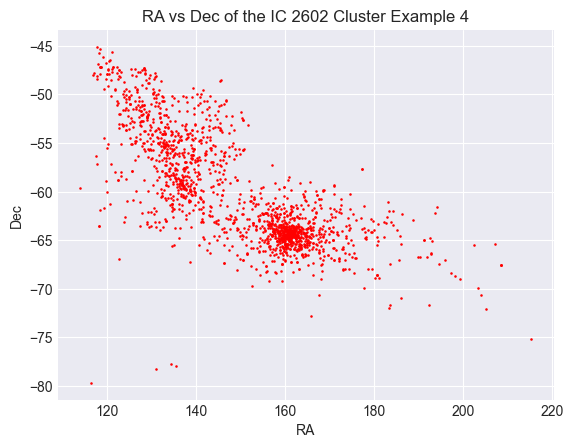

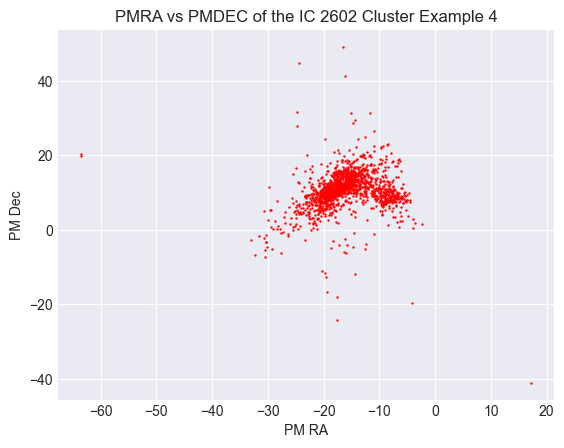

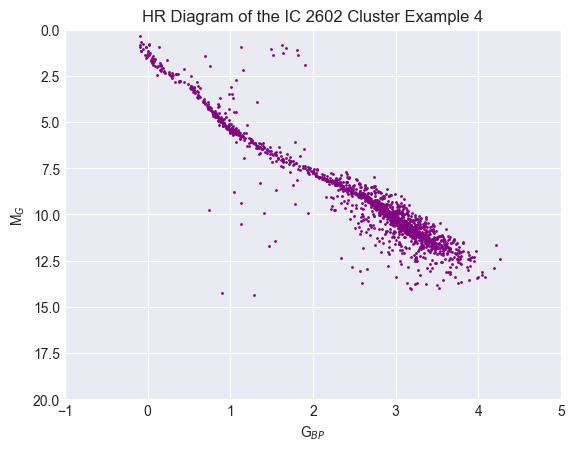

Median: 149.28215442956312, standard deviation: 231.62611949532482
Standard Deviation: 231.62611949532482


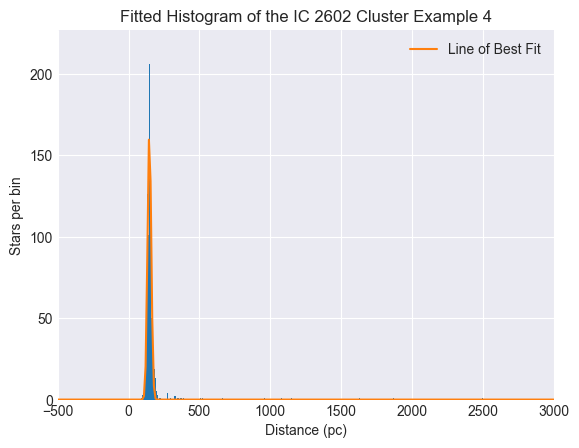

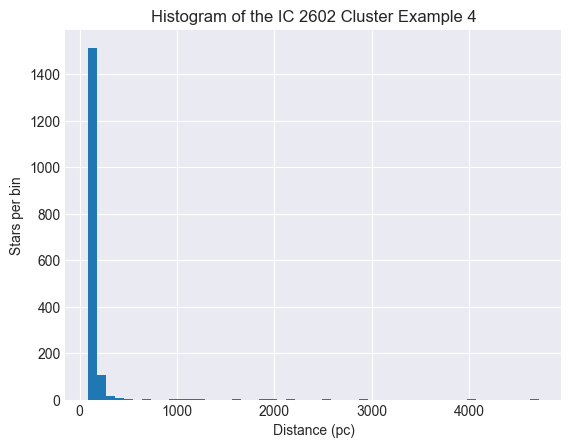

In [7]:
#Now the data will be used to plot simple functions in our mean photometry module. 
#We won't be saving the plots in this example, but if wanted, the save_plot parameter can be set to True and a file_name and save_folder can be given to save the plots with a specific name and in a specific folder.


#Each function, as seen below, is called using the mean_photometry module as mphot. Although is can be imported as any variable. Then the function is written in the form of modname.function_name(parameters)

mphot.ra_vs_dec(df, title = "RA vs Dec of the IC 2602 Cluster Example 4")
mphot.pmra_vs_pmdec(df, title = "PMRA vs PMDEC of the IC 2602 Cluster Example 4")
mphot.plot_hr_diagram(df, title = "HR Diagram of the IC 2602 Cluster Example 4")
mphot.fitted_hist(values=df['parallax'], parallax=True, title = "Fitted Histogram of the IC 2602 Cluster Example 4", bin_num = 1300, range = [-500, 3000])
mphot.hist(values=df['parallax'], parallax=True, title = "Histogram of the IC 2602 Cluster Example 4")
